# Customer Intelligence & Revenue Optimization

## Objective
Analyze customer shopping behavior and generate actionable business insights that can help improve customer understanding and optimize revenue.

## Dataset
Customer Shopping Behavior Dataset

## Tools Used
- Python
- Pandas
- SQL
- Power BI

## Project Workflow
1. Dataset Understanding
2. Data Audit
3. Business Questions
4. SQL Analysis
5. Advanced Python Analysis
6. Business Insights
7. Power BI Dashboard
8. Documentation

In [22]:
import pandas as pd
df=pd.read_csv("customer_shopping_behavior.csv")
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


#Data understanding and audit

In [23]:
df.shape

(3900, 18)

In [24]:
df.columns

Index(['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category',
       'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season',
       'Review Rating', 'Subscription Status', 'Shipping Type',
       'Discount Applied', 'Promo Code Used', 'Previous Purchases',
       'Payment Method', 'Frequency of Purchases'],
      dtype='object')

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [26]:
df.isnull().sum()

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

In [27]:
df.duplicated().sum()

np.int64(0)

In [28]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3863.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.750065,25.351538
std,1125.977353,15.207589,23.685392,0.716983,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.800000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [29]:
#Feature Enginnering
def Age_Group(Age):
    if Age <= 25:
        return 'Young Adult'
    elif Age <= 35:
        return 'Adult'
    elif Age <= 50:
        return 'Middle Age'
    else:
        return 'Senior'
df['Age_Group'] = df['Age'].apply(Age_Group)

In [30]:
df[['Age', 'Age_Group']].head()

,Age,Age_Group
0,55,Senior
1,19,Young Adult
2,50,Middle Age
3,21,Young Adult
4,45,Middle Age


In [31]:
df['Age_Group'].value_counts()

Age_Group
Senior         1476
Middle Age     1111
Adult           742
Young Adult     571
Name: count, dtype: int64

In [32]:
def loyalty_segment(previous_purchases):
    if previous_purchases <= 10:
        return 'New Customer'
    elif previous_purchases <= 30:
        return 'Returning Customer'
    else:
        return 'Loyal Customer'
df['loyalty_segment'] = df['Previous Purchases'].apply(loyalty_segment)

In [33]:
df['loyalty_segment'].value_counts()

loyalty_segment
Returning Customer    1567
Loyal Customer        1549
New Customer           784
Name: count, dtype: int64

### Business Questions

1. Which age groups contribute the highest revenue?

2. How does spending behavior differ between male and female customers?

3. Do subscribed customers spend more than non-subscribed customers?

4. How does customer loyalty influence spending behavior?

5. Which product categories generate the highest revenue and attract the most customers?

6. How do seasonal trends influence customer spending and product demand?

7. Do discounts encourage higher customer spending?

8. Which payment methods are preferred by high-spending customers?

9. Are repeat buyers more likely to subscribe?

10. Which Age Group and Product Category combination generates the highest revenue?

In [39]:
df.to_csv("customer_behavior_final.csv", index=False)

In [40]:
df.columns

Index(['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category',
       'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season',
       'Review Rating', 'Subscription Status', 'Shipping Type',
       'Discount Applied', 'Promo Code Used', 'Previous Purchases',
       'Payment Method', 'Frequency of Purchases', 'Age_Group',
       'loyalty_segment'],
      dtype='object')

In [41]:
(df['Discount Applied'] == df['Promo Code Used']).all()

np.True_

In [42]:
# Select numerical columns

num_cols = ['Age',
            'Purchase Amount (USD)',
            'Review Rating',
            'Previous Purchases']

# Correlation matrix
corr_matrix = df[num_cols].corr()

corr_matrix

,Age,Purchase Amount (USD),Review Rating,Previous Purchases
Age,1.000000,-0.010424,-0.024384,0.040445
Purchase Amount (USD),-0.010424,1.000000,0.029859,0.008063
Review Rating,-0.024384,0.029859,1.000000,0.003583
Previous Purchases,0.040445,0.008063,0.003583,1.000000


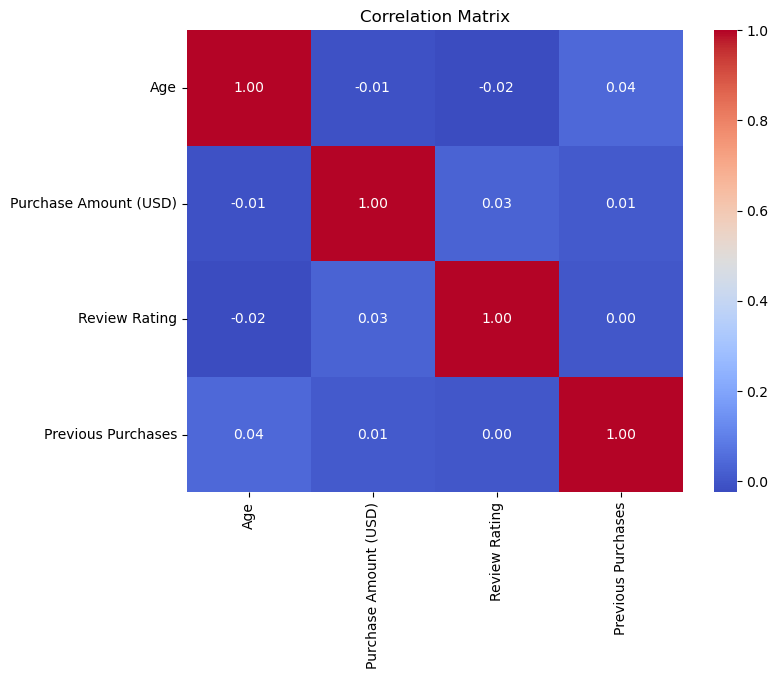

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title('Correlation Matrix')
plt.show()